# Power spectral density
Analysis of the power spectral density of raw data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import os

In [2]:
# Load raw data
df = pd.read_csv("../data/raw.csv")
print(f"Data shape: {df.shape}")
print(f"Data columns: {df.columns.tolist()}")
print(df.head())

Data shape: (100, 3)
Data columns: ['x', 'y', 'z']
          x         y         z
0  0.660657  0.647480 -0.955691
1  0.871440  0.755601  0.189053
2  0.197088  0.693719  0.944442
3  0.280773  0.913150  0.104642
4  0.512505  0.087505  0.469811


Figure saved to ../paper/figures/raw-data-spectra.png


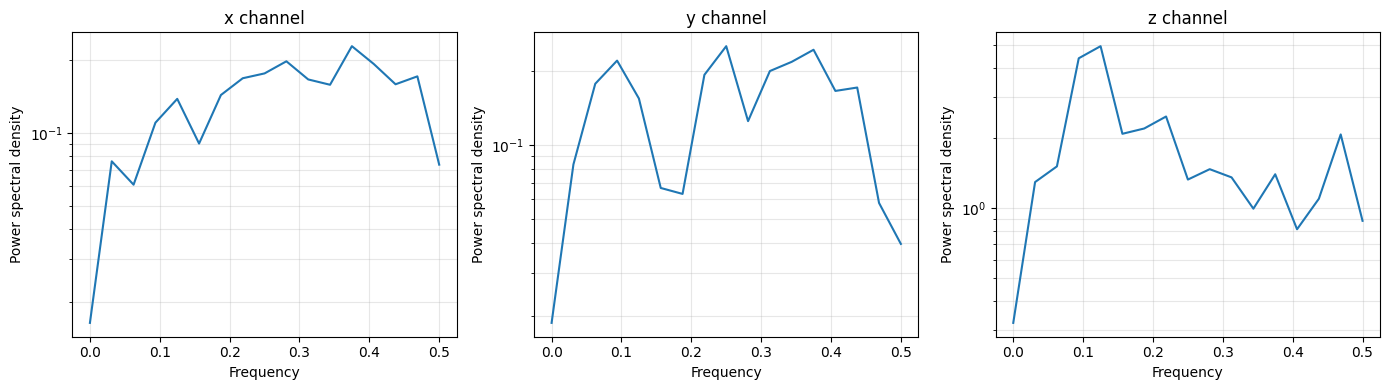

In [3]:
# Calculate power spectral density for each column
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, col in enumerate(df.columns):
    # Calculate PSD using Welch's method
    frequencies, psd = signal.welch(df[col].values, fs=1.0, nperseg=32)
    axes[idx].semilogy(frequencies, psd)
    axes[idx].set_xlabel("Frequency")
    axes[idx].set_ylabel("Power spectral density")
    axes[idx].set_title(f"{col} channel")
    axes[idx].grid(True, which="both", alpha=0.3)

plt.tight_layout()

# Create figures directory if it doesn't exist
os.makedirs("../paper/figures", exist_ok=True)

# Save figure
fpath = "../paper/figures/raw-data-spectra.png"
plt.savefig(fpath, dpi=300, bbox_inches="tight")
print(f"Figure saved to {fpath}")
plt.show()